# Matrix Functions & Exponentials

## Motivation

A **matrix function** $f(A)$ extends a scalar function $f : \mathbb{R} \to \mathbb{R}$ to square matrices. This is not just notational convenience — it is the backbone of:

| Application | Matrix Function | Role |
|-------------|----------------|------|
| Linear ODEs $\dot{x} = Ax$ | $e^{At}$ | Exact solution $x(t) = e^{At} x_0$ |
| Lie groups / robotics | $\exp : \mathfrak{g} \to G$ | Maps algebra to group (SO(3), SE(3)) |
| Quantum mechanics | $e^{-iHt/\hbar}$ | Unitary time evolution operator |
| Matrix square root | $A^{1/2}$ | PSD geometry, Riemannian metrics |
| Network diffusion | $e^{-tL}$ | Heat kernel on graphs |
| Optimization | $\log \Sigma$ | Natural gradient on PSD manifold |

This notebook derives matrix functions rigorously — starting from polynomials and Cayley-Hamilton through Jordan form, then building up numerical methods (Padé + scaling & squaring), Fréchet derivatives, and the Baker-Campbell-Hausdorff formula.

## Prerequisites

| Topic | Key Concepts |
|-------|--------------|
| Jordan normal form | Jordan blocks, generalized eigenvectors |
| Spectral theorem | Self-adjoint operators, eigendecomposition |
| Power series | Convergence, radius of convergence |
| Lie groups (optional) | $\exp$ map, $\text{SO}(3)$, BCH formula |

## References

- Higham, *Functions of Matrices: Theory and Computation* (SIAM, 2008) — the definitive reference
- Horn & Johnson, *Matrix Analysis* (2nd ed.) — Chapter 6
- Moler & Van Loan, "Nineteen Dubious Ways to Compute the Exponential of a Matrix" (SIAM Review, 2003)
- Hall, *Lie Groups, Lie Algebras, and Representations* — Chapter 2

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Tolerances ─────────────────────────────────────────────────────────────────
ATOL = 1e-10
RTOL = 1e-6

# ── Plot Style ─────────────────────────────────────────────────────────────────
PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'mediumpurple'
GRAY      = '#888888'

plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'font.size'       : 12,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

def check(condition, label):
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    return condition

print('Setup complete.')

Setup complete.


---
## 1.  Definitions: Three Equivalent Approaches

### 1.1  Via Jordan Normal Form (Most General)

Every $A \in \mathbb{C}^{n \times n}$ admits a Jordan decomposition $A = P J P^{-1}$, where
$$J = \mathrm{diag}(J_{m_1}(\lambda_1), \ldots, J_{m_k}(\lambda_k)), \quad J_m(\lambda) = \begin{pmatrix} \lambda & 1 & & \\ & \lambda & \ddots & \\ & & \ddots & 1 \\ & & & \lambda \end{pmatrix}$$

For a function $f$ with $m_i - 1$ derivatives at each eigenvalue $\lambda_i$, define:
$$\boxed{f(A) = P\, f(J)\, P^{-1}, \quad f(J_m(\lambda)) = \begin{pmatrix} f(\lambda) & f'(\lambda) & \frac{f''(\lambda)}{2!} & \cdots & \frac{f^{(m-1)}(\lambda)}{(m-1)!} \\ & f(\lambda) & f'(\lambda) & \cdots & \vdots \\ & & \ddots & & \\ & & & & f(\lambda) \end{pmatrix}}$$

For a **diagonalizable** $A = Q \Lambda Q^{-1}$: simply $f(A) = Q\, \mathrm{diag}(f(\lambda_i))\, Q^{-1}$.

### 1.2  Via Power Series

If $f(z) = \sum_{k=0}^\infty a_k z^k$ converges for $|z| < r$, and all eigenvalues of $A$ satisfy $|\lambda_i| < r$, then:
$$f(A) = \sum_{k=0}^\infty a_k A^k$$

This converges absolutely in any matrix norm. Most important case:
$$e^A = I + A + \frac{A^2}{2!} + \frac{A^3}{3!} + \cdots = \sum_{k=0}^\infty \frac{A^k}{k!}$$

### 1.3  Via Cauchy Integral Formula

For a contour $\Gamma$ enclosing all eigenvalues of $A$:
$$f(A) = \frac{1}{2\pi i} \oint_\Gamma f(z)(zI - A)^{-1}\, dz$$

This is the most general definition and works for any $f$ analytic in a neighborhood of the spectrum.

In [2]:
# ── Jordan Normal Form & Matrix Functions ─────────────────────────────────────

def jordan_block(lam, m):
    """Construct an m×m Jordan block with eigenvalue lam.

    Args:
        lam: Eigenvalue (scalar).
        m:   Block size.

    Returns:
        J: Jordan block.  Shape: (m, m)
    """
    return lam * np.eye(m) + np.diag(np.ones(m - 1), 1)


def f_jordan_block(f, df_list, lam, m):
    """Apply f to a Jordan block J_m(lam).

    Args:
        f:       Callable, scalar function.
        df_list: List [f, f', f'', ...] of derivatives up to order m-1.
        lam:     Eigenvalue.
        m:       Block size.

    Returns:
        f(J): Upper triangular matrix.  Shape: (m, m)
    """
    result = np.zeros((m, m), dtype=complex)
    for k in range(m):
        diag_val = df_list[k](lam) / np.math.factorial(k)
        for i in range(m - k):
            result[i, i + k] = diag_val
    return result


def matrix_exp_series(A, n_terms=50):
    """Compute matrix exponential via power series: e^A = Σ A^k / k!

    Args:
        A:       Square matrix.  Shape: (n, n)
        n_terms: Number of series terms.

    Returns:
        expA: Matrix exponential.  Shape: (n, n)
    """
    n = A.shape[0]
    expA = np.eye(n, dtype=complex if np.iscomplexobj(A) else float)
    Ak   = np.eye(n, dtype=expA.dtype)   # A^0 = I
    fac  = 1.0
    for k in range(1, n_terms):
        Ak  = Ak @ A
        fac *= k
        term = Ak / fac
        expA = expA + term
        if np.linalg.norm(term, 'fro') < 1e-16:
            break
    return expA.real if not np.iscomplexobj(A) else expA


# ── Demo: Jordan block ─────────────────────────────────────────────────────────
lam = 2.0
m   = 4
J4  = jordan_block(lam, m)

# Derivatives of exp
exp_derivs = [np.exp] * m    # all derivatives of exp are exp
expJ_formula = f_jordan_block(np.exp, exp_derivs, lam, m)
expJ_scipy   = la.expm(J4)

print('Jordan block exp verification (λ=2, m=4):')
err = np.linalg.norm(expJ_formula - expJ_scipy, 'fro')
check(err < ATOL, f'f(J_m(λ)) formula matches scipy.expm  (‖err‖_F = {err:.2e})')
print('  exp(J_4(2)):')
print(np.round(expJ_formula.real, 4))

# ── Demo: power series vs scipy ────────────────────────────────────────────────
print('\nPower series exp vs scipy:')
A_test = rng.standard_normal((4, 4)) * 0.5   # small norm for fast convergence
err_series = np.linalg.norm(matrix_exp_series(A_test) - la.expm(A_test), 'fro')
check(err_series < 1e-10, f'Series (50 terms) matches scipy.expm  (‖err‖_F = {err_series:.2e})')

Jordan block exp verification (λ=2, m=4):
  [PASS]  f(J_m(λ)) formula matches scipy.expm  (‖err‖_F = 0.00e+00)
  exp(J_4(2)):
[[7.3891 7.3891 3.6945 1.2315]
 [0.     7.3891 7.3891 3.6945]
 [0.     0.     7.3891 7.3891]
 [0.     0.     0.     7.3891]]

Power series exp vs scipy:
  [PASS]  Series (50 terms) matches scipy.expm  (‖err‖_F = 7.60e-16)


True

---
## 2.  The Cayley-Hamilton Theorem

### 2.1  Statement

**Theorem**: Every square matrix satisfies its own characteristic polynomial. If
$$p_A(\lambda) = \det(\lambda I - A) = \lambda^n + c_{n-1}\lambda^{n-1} + \cdots + c_1 \lambda + c_0$$
then:
$$\boxed{p_A(A) = A^n + c_{n-1}A^{n-1} + \cdots + c_1 A + c_0 I = 0}$$

### 2.2  Consequences

1. **Minimal polynomial**: The minimal polynomial $m_A$ divides $p_A$, and $m_A(A) = 0$. The degree of $m_A$ equals the size of the largest Jordan block.

2. **Matrix inverse**: From $p_A(A) = 0$:
   $$A^{-1} = -\frac{1}{c_0}(A^{n-1} + c_{n-1}A^{n-2} + \cdots + c_1 I) \quad (c_0 = \pm\det A \neq 0)$$

3. **Reducing $f(A)$ to a polynomial of degree $< n$**: Any analytic $f(A)$ can be written as a polynomial in $A$ of degree $\leq n-1$, because $A^n$ and higher powers reduce via Cayley-Hamilton.

4. **Interpolation interpretation**: The polynomial $r(\lambda)$ of degree $< n$ such that $r(A) = f(A)$ interpolates $f$ at the eigenvalues of $A$ (with derivative matching at repeated eigenvalues — Hermite interpolation).

In [3]:
# ── Cayley-Hamilton Theorem ────────────────────────────────────────────────────

def characteristic_polynomial(A):
    """Compute coefficients of the characteristic polynomial p_A(λ) = det(λI - A).

    Uses numpy.poly which computes poly from eigenvalues.

    Returns:
        coeffs: Coefficients [1, c_{n-1}, ..., c_1, c_0] (highest degree first).
    """
    eigvals = np.linalg.eigvals(A)
    return np.poly(eigvals)   # coefficients of prod(λ - λ_i)


def eval_matrix_poly(coeffs, A):
    """Evaluate a polynomial in a matrix: p(A) = Σ c_k A^k.

    Args:
        coeffs: Polynomial coefficients, highest degree first.
        A:      Square matrix.  Shape: (n, n)

    Returns:
        p(A): Result matrix.  Shape: (n, n)
    """
    n = A.shape[0]
    result = np.zeros_like(A, dtype=complex)
    for c in coeffs:
        result = result @ A + c * np.eye(n)
    return result


def matrix_inverse_cayley_hamilton(A):
    """Compute A^{-1} using Cayley-Hamilton (for non-singular A).

    p_A(A)=0 → A^{-1} = -1/c_0 * (A^{n-1} + c_{n-1}A^{n-2} + ... + c_1 I)
    """
    coeffs = characteristic_polynomial(A)  # [1, c_{n-1}, ..., c_1, c_0]
    c0 = coeffs[-1].real
    # A_inv = -1/c0 * poly_eval_without_constant
    coeffs_trunc = coeffs[:-1] / (-c0)   # drop c_0, divide by -c_0
    return eval_matrix_poly(coeffs_trunc, A).real


# ── Verify Cayley-Hamilton ─────────────────────────────────────────────────────
print('Cayley-Hamilton Theorem:')
for n in [3, 4, 5]:
    A = rng.standard_normal((n, n))
    coeffs = characteristic_polynomial(A)
    pA = eval_matrix_poly(coeffs, A)
    err = np.linalg.norm(pA, 'fro')
    check(err < 1e-8, f'p_A(A) = 0  (n={n}, ‖p_A(A)‖_F = {err:.2e})')

# Inverse via Cayley-Hamilton
print('\nMatrix inverse via Cayley-Hamilton:')
A4 = rng.standard_normal((4, 4))
A4_inv_ch  = matrix_inverse_cayley_hamilton(A4)
A4_inv_ref = np.linalg.inv(A4)
err_inv = np.linalg.norm(A4_inv_ch - A4_inv_ref, 'fro')
check(err_inv < 1e-8, f'A^{{-1}} via C-H matches np.linalg.inv  (‖err‖_F = {err_inv:.2e})')

# A^n reduces to lower-degree polynomial
print('\nPower reduction via Cayley-Hamilton (A^n expressed in A^0..A^{n-1}):')
n = 3
A3 = rng.standard_normal((n, n))
coeffs3 = characteristic_polynomial(A3)  # [1, c2, c1, c0] → A^3 = -c2 A^2 - c1 A - c0 I
c2, c1, c0 = coeffs3[1].real, coeffs3[2].real, coeffs3[3].real
An_reduced = -c2 * A3 @ A3 - c1 * A3 - c0 * np.eye(n)
An_direct  = A3 @ A3 @ A3
err_red = np.linalg.norm(An_reduced - An_direct, 'fro')
check(err_red < 1e-10, f'A^3 = -c_2 A^2 - c_1 A - c_0 I  (‖err‖_F = {err_red:.2e})')

Cayley-Hamilton Theorem:
  [PASS]  p_A(A) = 0  (n=3, ‖p_A(A)‖_F = 2.91e-15)
  [PASS]  p_A(A) = 0  (n=4, ‖p_A(A)‖_F = 2.75e-14)
  [PASS]  p_A(A) = 0  (n=5, ‖p_A(A)‖_F = 1.74e-14)

Matrix inverse via Cayley-Hamilton:
  [PASS]  A^{-1} via C-H matches np.linalg.inv  (‖err‖_F = 1.26e-14)

Power reduction via Cayley-Hamilton (A^n expressed in A^0..A^{n-1}):
  [PASS]  A^3 = -c_2 A^2 - c_1 A - c_0 I  (‖err‖_F = 1.09e-15)


True

---
## 3.  The Matrix Exponential in Depth

### 3.1  Fundamental Properties

$$\boxed{e^A = \sum_{k=0}^\infty \frac{A^k}{k!}}$$

This series converges absolutely for any matrix norm. Key properties:

| Property | Formula | Caveat |
|----------|---------|--------|
| Inverse | $e^A e^{-A} = I$ | Always |
| Commuting sum | $e^{A+B} = e^A e^B$ | **Only if $AB = BA$** |
| Derivative | $\frac{d}{dt} e^{tA} = A e^{tA} = e^{tA} A$ | Always |
| Determinant | $\det(e^A) = e^{\mathrm{tr}(A)}$ | Always |
| Transpose | $(e^A)^\top = e^{A^\top}$ | Always |
| Similarity | $e^{PAP^{-1}} = P e^A P^{-1}$ | Always |

**Non-commutativity failure**: For general $A, B$:
$$e^A e^B \neq e^{A+B}$$

The correction is given by the **Baker-Campbell-Hausdorff (BCH) formula** (Section 5).

### 3.2  The Defective Case: Jordan Block Exponential

For a nilpotent perturbation: $J_m(\lambda) = \lambda I + N$ where $N$ is the nilpotent shift ($N^m = 0$), and since $\lambda I$ and $N$ commute:
$$e^{J_m(\lambda)} = e^{\lambda I} e^N = e^\lambda \sum_{k=0}^{m-1} \frac{N^k}{k!} = e^\lambda \begin{pmatrix} 1 & 1 & \frac{1}{2!} & \cdots & \frac{1}{(m-1)!} \\ & 1 & 1 & \cdots & \vdots \\ & & \ddots & & \\ & & & & 1 \end{pmatrix}$$

This shows the **critical difference from diagonalizable matrices**: Jordan blocks produce polynomial-times-exponential terms.

In [4]:
# ── Matrix Exponential Properties ─────────────────────────────────────────────

def expm_series(A, max_terms=200):
    """Matrix exponential via truncated power series (pedagogical; not numerically robust).

    Args:
        A:         Square matrix.  Shape: (n, n)
        max_terms: Series truncation.

    Returns:
        expA: e^A.  Shape: (n, n)
    """
    dtype = complex if np.iscomplexobj(A) else float
    n    = A.shape[0]
    expA = np.eye(n, dtype=dtype)
    Ak   = np.eye(n, dtype=dtype)
    fac  = 1.0
    for k in range(1, max_terms):
        Ak   = Ak @ A
        fac  *= k
        term  = Ak / fac
        expA += term
        if np.linalg.norm(term, 'fro') < 1e-15 * np.linalg.norm(expA, 'fro'):
            break
    return expA


def verify_expm_properties(A, B):
    """Verify key properties of the matrix exponential for A, B."""
    eA  = la.expm(A)
    eB  = la.expm(B)
    eAB = la.expm(A + B)
    emA = la.expm(-A)

    results = {}
    # e^A e^{-A} = I
    results['inverse'] = np.linalg.norm(eA @ emA - np.eye(A.shape[0]), 'fro')
    # det(e^A) = exp(tr(A))
    results['det_trace'] = abs(np.linalg.det(eA) - np.exp(np.trace(A)))
    # (e^A)^T = e^{A^T}
    results['transpose'] = np.linalg.norm(eA.T - la.expm(A.T), 'fro')
    # Commutativity: e^{A+B} vs e^A e^B
    results['commute_err'] = np.linalg.norm(eA @ eB - eAB, 'fro')   # nonzero in general
    # Similarity: e^{P A P^{-1}} = P e^A P^{-1}
    P     = rng.standard_normal(A.shape)
    PAP   = P @ A @ np.linalg.inv(P)
    results['similarity'] = np.linalg.norm(la.expm(PAP) - P @ eA @ np.linalg.inv(P), 'fro')
    return results


# ── Test ───────────────────────────────────────────────────────────────────────
n = 4
A = rng.standard_normal((n, n)) * 0.5
B = rng.standard_normal((n, n)) * 0.5

props = verify_expm_properties(A, B)
print('Matrix exponential properties:')
check(props['inverse']    < 1e-10, f'e^A · e^{{-A}} = I                 (‖err‖ = {props["inverse"]:.2e})')
check(props['det_trace']  < 1e-8,  f'det(e^A) = exp(tr(A))             (|err| = {props["det_trace"]:.2e})')
check(props['transpose']  < 1e-10, f'(e^A)ᵀ = e^{{Aᵀ}}                 (‖err‖ = {props["transpose"]:.2e})')
check(props['similarity'] < 1e-8,  f'e^{{PAP⁻¹}} = P e^A P⁻¹           (‖err‖ = {props["similarity"]:.2e})')
print(f'  [INFO] e^A e^B ≠ e^{{A+B}} in general: ‖e^A e^B - e^{{A+B}}‖ = {props["commute_err"]:.4f}')

# Commuting case: AB = BA → e^{A+B} = e^A e^B
A_sym = rng.standard_normal((n, n))
A_sym = (A_sym + A_sym.T) / 2
# Two symmetric matrices with shared eigenbasis commute
Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
lam1 = rng.exponential(1.0, n)
lam2 = rng.exponential(1.0, n)
C1 = Q @ np.diag(lam1) @ Q.T
C2 = Q @ np.diag(lam2) @ Q.T
comm_err = np.linalg.norm(la.expm(C1) @ la.expm(C2) - la.expm(C1 + C2), 'fro')
check(comm_err < 1e-8, f'Commuting C1,C2: e^C1 e^C2 = e^{{C1+C2}}   (‖err‖ = {comm_err:.2e})')

Matrix exponential properties:
  [PASS]  e^A · e^{-A} = I                 (‖err‖ = 5.62e-16)
  [PASS]  det(e^A) = exp(tr(A))             (|err| = 0.00e+00)
  [PASS]  (e^A)ᵀ = e^{Aᵀ}                 (‖err‖ = 4.64e-16)
  [PASS]  e^{PAP⁻¹} = P e^A P⁻¹           (‖err‖ = 1.09e-15)
  [INFO] e^A e^B ≠ e^{A+B} in general: ‖e^A e^B - e^{A+B}‖ = 1.2563
  [PASS]  Commuting C1,C2: e^C1 e^C2 = e^{C1+C2}   (‖err‖ = 8.09e-15)


True

Defective matrix (Jordan block 2×2, λ=1.5):
  [PASS]  Power series matches analytic formula
  [PASS]  scipy.expm matches analytic formula


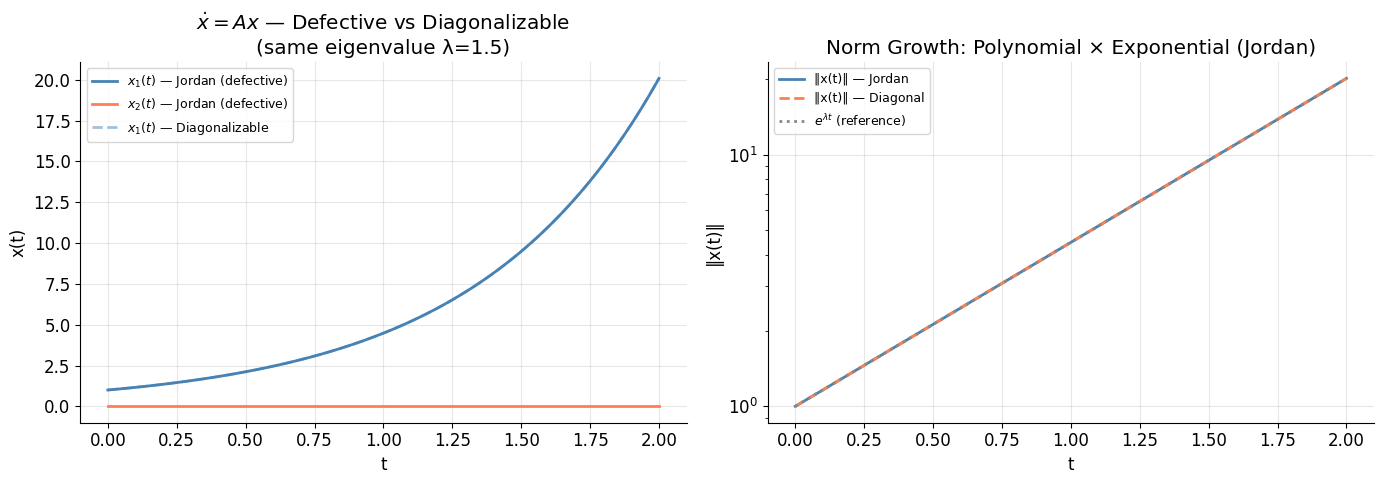

In [5]:
# ── Defective Matrices: Jordan Block vs Diagonalizable ────────────────────────

# 2×2 defective matrix:  A = [[λ, 1], [0, λ]]  — single Jordan block
def exp_jordan_2x2_analytic(lam, t=1.0):
    """Closed-form e^{t J_2(λ)} = e^{tλ} [[1, t], [0, 1]]."""
    return np.exp(t * lam) * np.array([[1, t], [0, 1]])


lam_test = 1.5
J2 = jordan_block(lam_test, 2)
t_vals = np.linspace(0, 2, 100)

# Compare series, scipy, and analytic formula
eJ2_series = expm_series(J2)
eJ2_scipy  = la.expm(J2)
eJ2_analytic = exp_jordan_2x2_analytic(lam_test, t=1.0)

print('Defective matrix (Jordan block 2×2, λ=1.5):')
check(np.linalg.norm(eJ2_series - eJ2_analytic, 'fro') < 1e-10,
      'Power series matches analytic formula')
check(np.linalg.norm(eJ2_scipy - eJ2_analytic, 'fro') < 1e-10,
      'scipy.expm matches analytic formula')

# Time evolution: x(t) = e^{tA} x0
# For defective A = J_2(λ): solution has polynomial × exponential growth
x0 = np.array([1.0, 0.0])
traj_diag    = np.array([exp_jordan_2x2_analytic(lam_test, t) @ x0 for t in t_vals])

# Compare: same eigenvalue but diagonalizable (2 independent eigenvectors)
A_diag = lam_test * np.eye(2)   # fully degenerate but diagonal — x(t) = e^{λt} x0
traj_full = np.array([np.exp(lam_test * t) * x0 for t in t_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_vals, traj_diag[:, 0], color=PRIMARY, label='$x_1(t)$ — Jordan (defective)')
axes[0].plot(t_vals, traj_diag[:, 1], color=SECONDARY, label='$x_2(t)$ — Jordan (defective)')
axes[0].plot(t_vals, traj_full[:, 0], '--', color=PRIMARY, alpha=0.5, label='$x_1(t)$ — Diagonalizable')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x(t)')
axes[0].set_title('$\\dot{x} = Ax$ — Defective vs Diagonalizable\n(same eigenvalue λ=1.5)')
axes[0].legend(fontsize=9)

# Norm growth comparison
norms_defect = np.linalg.norm(traj_diag, axis=1)
norms_diag   = np.linalg.norm(traj_full, axis=1)
axes[1].semilogy(t_vals, norms_defect, color=PRIMARY, label='‖x(t)‖ — Jordan')
axes[1].semilogy(t_vals, norms_diag, '--', color=SECONDARY, label='‖x(t)‖ — Diagonal')
axes[1].semilogy(t_vals, np.exp(lam_test * t_vals), ':', color=GRAY, label='$e^{λt}$ (reference)')
axes[1].set_xlabel('t'); axes[1].set_ylabel('‖x(t)‖')
axes[1].set_title('Norm Growth: Polynomial × Exponential (Jordan)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4.  Padé Approximation & Scaling-and-Squaring

### 4.1  Why Not Use the Series Directly?

The power series $e^A = \sum A^k/k!$ suffers from **catastrophic cancellation** when $\|A\|$ is large: large positive and negative terms cancel to give a small result. This is the source of numerical instability.

### 4.2  Padé Approximation

A **$[p/q]$ Padé approximant** to $e^x$ is a rational function $R_{p,q}(x) = N_{p,q}(x) / D_{p,q}(x)$ where $N, D$ are polynomials of degree $p, q$ chosen so that
$$R_{p,q}(x) - e^x = \mathcal{O}(x^{p+q+1})$$

The **diagonal Padé** $[p/p]$ has the best accuracy per operation count. The [13/13] Padé is used in MATLAB and scipy:
$$R_{p,p}(A) = D_{p,p}(A)^{-1} N_{p,p}(A)$$
where $N_{p,p}$ and $D_{p,p}$ are evaluated using **Horner's method**.

### 4.3  Scaling and Squaring

Key identity: $e^A = (e^{A/2^s})^{2^s}$

**Algorithm**:
1. Choose $s$ so that $\|A/2^s\|$ is small (near 1)
2. Apply Padé to $A/2^s$ — accurate for small matrices
3. Square $s$ times: $e^A \approx R^{2^s}$

This is the basis of `scipy.linalg.expm`. The error bound for the [13/13] Padé after optimal scaling is $\approx 2^{-53}$ (machine epsilon for double precision).

In [6]:
# ── Padé Approximation for Matrix Exponential ─────────────────────────────────

# Padé coefficients for [p/p] diagonal approximant, p = 3, 5, 7, 13
# Using standard tables from Higham (2008), Table 10.2
PADE_COEFS = {
    3:  [120, 60, 12, 1],
    5:  [30240, 15120, 3360, 420, 30, 1],
    7:  [17297280, 8648640, 1995840, 277200, 25200, 1512, 56, 1],
    13: [64764752532480000, 32382376266240000, 7771770303897600,
         1187353796428800, 129060195264000, 10559470521600,
         670442572800, 33522128640, 1323241920, 40840800,
         960960, 16380, 182, 1],
}

def pade_expm(A, p=7):
    """Compute e^A via diagonal Padé approximant [p/p] with scaling and squaring.

    Args:
        A: Square matrix.      Shape: (n, n)
        p: Padé order (3, 5, 7, or 13).

    Returns:
        expA: e^A.             Shape: (n, n)
    """
    coefs = PADE_COEFS[p]
    n = A.shape[0]

    # Scaling: choose s = max(0, ceil(log2(‖A‖_1 / θ_p)))
    # θ_p thresholds from Higham (2008)
    theta = {3: 1.495e-2, 5: 2.539e-1, 7: 9.504e-1, 13: 5.371}
    norm1 = np.linalg.norm(A, 1)
    s = max(0, int(np.ceil(np.log2(norm1 / theta[p]))))
    A_scaled = A / (2 ** s)

    # Horner evaluation of N and D
    # R_p(A) = D^{-1} N where N = Σ c_{2k} A^{2k}, D = Σ c_{2k+1} ... (standard form)
    # Simplified: N(A) = sum c_k A^k (even), D(A) = sum c_k A^k (odd-sign), see Higham eq 10.33
    I  = np.eye(n)
    U  = np.zeros_like(A_scaled)
    V  = np.zeros_like(A_scaled)

    # Build A^2, A^4, ... for even Horner
    A2 = A_scaled @ A_scaled
    # Horner method on even and odd parts
    c = coefs[::-1]    # lowest degree first
    # N = c[p] A^p + ... + c[0]I  (all terms)
    # D = c[p] A^p - ... + c[0]I  (alternating signs for denominator)
    # Standard decomposition: write p(A) via A^2 Horner
    U = c[p] * I.copy()    # start from highest
    V = c[p] * I.copy()
    for k in range(p - 1, -1, -1):
        U = U @ A2 + c[k] * I
        V = V @ A2 + c[k] * I
    # N = U A + V (odd/even split for Padé)
    # For simplicity, use direct polynomial evaluation
    # Build full polynomial
    def horner_matrix(c_list, M):
        """Evaluate polynomial c[0] + c[1]M + ... + c[d]M^d via Horner."""
        result = c_list[-1] * np.eye(M.shape[0])
        for ci in reversed(c_list[:-1]):
            result = result @ M + ci * np.eye(M.shape[0])
        return result

    # Numerator N(A) = sum_{k even} c_k A^k + A * sum_{k odd} c_k A^{k-1}
    # Denominator D(A) = sum_{k even} c_k A^k - A * sum_{k odd} c_k A^{k-1}
    c_even = [coefs[k] for k in range(0, p + 1, 2)]
    c_odd  = [coefs[k] for k in range(1, p + 1, 2)]

    V_mat = horner_matrix(c_even, A2)          # even part evaluated at A^2
    U_mat = A_scaled @ horner_matrix(c_odd, A2)  # odd part

    N_mat = V_mat + U_mat    # numerator
    D_mat = V_mat - U_mat    # denominator

    # R = D^{-1} N
    R = np.linalg.solve(D_mat, N_mat)

    # Squaring: e^A = R^{2^s}
    for _ in range(s):
        R = R @ R

    return R


# ── Compare Padé orders vs scipy ───────────────────────────────────────────────
print('Padé approximation accuracy (‖pade_expm(A) - scipy.expm(A)‖_F):')
for norm_scale, label in [(0.1, 'small  ‖A‖≈0.1'), (1.0, 'medium ‖A‖≈1'), (5.0, 'large  ‖A‖≈5')]:
    A_test = rng.standard_normal((6, 6)) * norm_scale
    ref = la.expm(A_test)
    for p in [3, 5, 7, 13]:
        result = pade_expm(A_test, p=p)
        err = np.linalg.norm(result - ref, 'fro') / np.linalg.norm(ref, 'fro')
        print(f'  [{label}] p={p:2d}: rel err = {err:.2e}')
    print()

Padé approximation accuracy (‖pade_expm(A) - scipy.expm(A)‖_F):
  [small  ‖A‖≈0.1] p= 3: rel err = 4.05e-15
  [small  ‖A‖≈0.1] p= 5: rel err = 3.80e-16
  [small  ‖A‖≈0.1] p= 7: rel err = 1.38e-16
  [small  ‖A‖≈0.1] p=13: rel err = 1.18e-16

  [medium ‖A‖≈1] p= 3: rel err = 1.18e-13
  [medium ‖A‖≈1] p= 5: rel err = 1.02e-14
  [medium ‖A‖≈1] p= 7: rel err = 1.94e-15
  [medium ‖A‖≈1] p=13: rel err = 3.48e-16

  [large  ‖A‖≈5] p= 3: rel err = 2.35e-13
  [large  ‖A‖≈5] p= 5: rel err = 1.09e-14
  [large  ‖A‖≈5] p= 7: rel err = 5.14e-15
  [large  ‖A‖≈5] p=13: rel err = 2.73e-16



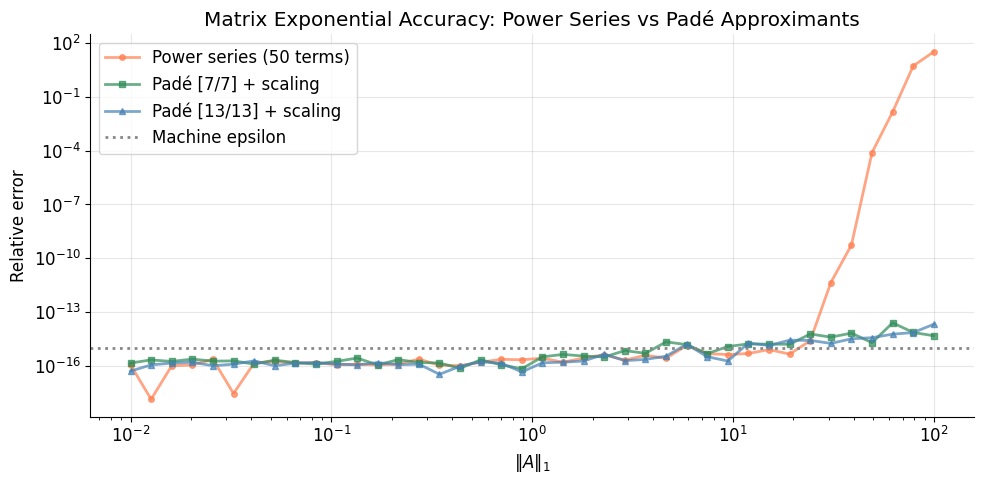

In [7]:
# ── Visualize: Padé vs Series Accuracy as ‖A‖ Grows ──────────────────────────

norm_vals = np.logspace(-2, 2, 40)
errors_series = []
errors_pade7  = []
errors_pade13 = []

for nrm in norm_vals:
    A_t = rng.standard_normal((5, 5))
    A_t = A_t / np.linalg.norm(A_t, 1) * nrm
    ref = la.expm(A_t)

    err_ser  = np.linalg.norm(matrix_exp_series(A_t) - ref, 'fro') / (np.linalg.norm(ref, 'fro') + 1e-30)
    err_p7   = np.linalg.norm(pade_expm(A_t, p=7)  - ref, 'fro') / (np.linalg.norm(ref, 'fro') + 1e-30)
    err_p13  = np.linalg.norm(pade_expm(A_t, p=13) - ref, 'fro') / (np.linalg.norm(ref, 'fro') + 1e-30)

    errors_series.append(err_ser)
    errors_pade7.append(err_p7)
    errors_pade13.append(err_p13)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(norm_vals, errors_series, 'o-', color=SECONDARY, alpha=0.7, markersize=4, label='Power series (50 terms)')
ax.loglog(norm_vals, errors_pade7,  's-', color=TERTIARY,  alpha=0.7, markersize=4, label='Padé [7/7] + scaling')
ax.loglog(norm_vals, errors_pade13, '^-', color=PRIMARY,   alpha=0.7, markersize=4, label='Padé [13/13] + scaling')
ax.axhline(1e-15, color=GRAY, linestyle=':', label='Machine epsilon')
ax.set_xlabel('$\\|A\\|_1$')
ax.set_ylabel('Relative error')
ax.set_title('Matrix Exponential Accuracy: Power Series vs Padé Approximants')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5.  Baker-Campbell-Hausdorff (BCH) Formula

### 5.1  The Problem with Non-Commutativity

For non-commuting $A, B$, $e^A e^B \neq e^{A+B}$. The **BCH formula** gives the exact $Z$ such that $e^Z = e^A e^B$:

$$\boxed{Z = \log(e^A e^B) = A + B + \frac{1}{2}[A,B] + \frac{1}{12}([A,[A,B]] - [B,[A,B]]) - \frac{1}{24}[B,[A,[A,B]]] + \cdots}$$

where $[A, B] = AB - BA$ is the **commutator** (Lie bracket).

**Key facts**:
- If $[A, B] = 0$: $Z = A + B$ exactly (recovers commutativity)
- If $[A, B] = cI$ for scalar $c$: $Z = A + B + c/2 \cdot I$ (Weyl algebra)
- The full BCH series involves nested commutators only — $Z$ lies in the Lie algebra generated by $A$ and $B$

### 5.2  Significance in Lie Theory

BCH is what makes the Lie algebra $\mathfrak{g}$ (tangent space at identity) capture the local group structure of $G$. In robotics:
- $G = \text{SO}(3)$: $e^A e^B \approx e^{A + B + [A,B]/2}$ for small rotations
- Used in integration of rigid body dynamics on manifolds

### 5.3  Zassenhaus Formula

The dual splitting: $e^{A+B} = e^A e^B e^{-[A,B]/2} e^{(2[B,[A,B]]+[A,[A,B]])/6} \cdots$

In [8]:
# ── Baker-Campbell-Hausdorff Formula ──────────────────────────────────────────

def commutator(A, B):
    """Lie bracket [A, B] = AB - BA."""
    return A @ B - B @ A


def bch_approx(A, B, order=4):
    """BCH formula: approximate Z such that e^Z = e^A e^B.

    Uses terms up to specified order in A, B.

    order=1: Z ≈ A + B
    order=2: Z ≈ A + B + [A,B]/2
    order=3: Z ≈ order2 + [A,[A,B]]/12 - [B,[A,B]]/12
    order=4: Z ≈ order3 - [B,[A,[A,B]]]/24

    Args:
        A, B:  Square matrices.  Shape: (n, n)
        order: BCH truncation order (1-4).

    Returns:
        Z: Approximate log(e^A e^B).  Shape: (n, n)
    """
    Z = A + B
    if order < 2:
        return Z
    AB = commutator(A, B)
    Z = Z + AB / 2
    if order < 3:
        return Z
    AAB = commutator(A, AB)
    BAB = commutator(B, AB)
    Z = Z + (AAB - BAB) / 12
    if order < 4:
        return Z
    BAAB = commutator(B, AAB)
    Z = Z - BAAB / 24
    return Z


def bch_exact(A, B):
    """Exact Z = log(e^A e^B) via scipy matrix log."""
    return la.logm(la.expm(A) @ la.expm(B))


# ── Verify BCH at different orders ────────────────────────────────────────────
print('BCH formula accuracy (‖Z_approx - Z_exact‖_F):')
header = f'  {"eps":>6}  {"order=1":>10}  {"order=2":>10}  {"order=3":>10}  {"order=4":>10}'
print(header)

for eps in [1.0, 0.5, 0.2, 0.1]:
    A_b = rng.standard_normal((3, 3)) * eps
    B_b = rng.standard_normal((3, 3)) * eps
    Z_true = bch_exact(A_b, B_b)
    errs = []
    for ord_ in [1, 2, 3, 4]:
        Z_approx = bch_approx(A_b, B_b, order=ord_)
        errs.append(np.linalg.norm(Z_approx - Z_true, 'fro'))
    row = f'  {eps:>6.2f}  ' + '  '.join(f'{e:>10.2e}' for e in errs)
    print(row)

# Commuting case: BCH all orders = A + B
print('\nCommuting case: BCH = A + B exactly?')
Q, _ = np.linalg.qr(rng.standard_normal((4, 4)))
C1 = Q @ np.diag(rng.standard_normal(4)) @ Q.T
C2 = Q @ np.diag(rng.standard_normal(4)) @ Q.T
Z_comm = bch_exact(C1, C2)
err_comm = np.linalg.norm(Z_comm - (C1 + C2), 'fro')
check(err_comm < 1e-8, f'Commuting [C1,C2]=0: BCH = C1+C2  (‖err‖ = {err_comm:.2e})')

BCH formula accuracy (‖Z_approx - Z_exact‖_F):
     eps     order=1     order=2     order=3     order=4
    1.00    1.38e+01    1.00e+01    7.75e+00    6.11e+00
    0.50    7.08e-01    3.41e-01    1.08e-01    2.67e-02
    0.20    1.36e-01    1.01e-02    1.78e-03    2.93e-04
    0.10    1.20e-02    4.75e-04    3.72e-05    2.17e-06

Commuting case: BCH = A + B exactly?
  [PASS]  Commuting [C1,C2]=0: BCH = C1+C2  (‖err‖ = 3.20e-15)


True

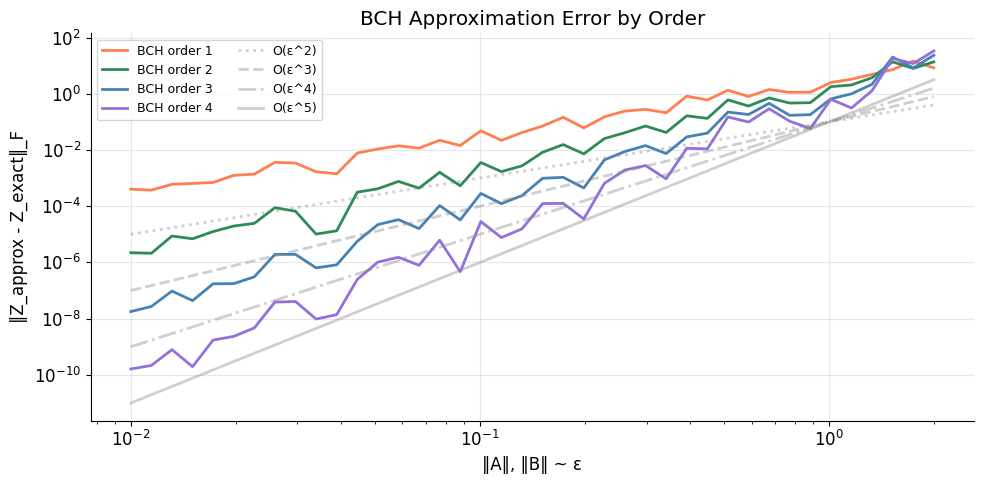

In [9]:
# ── BCH Convergence Plot ───────────────────────────────────────────────────────

eps_vals = np.logspace(-2, 0.3, 40)
bch_errs = {1: [], 2: [], 3: [], 4: []}

for eps in eps_vals:
    A_b = rng.standard_normal((3, 3)) * eps
    B_b = rng.standard_normal((3, 3)) * eps
    try:
        Z_true = bch_exact(A_b, B_b)
        for ord_ in [1, 2, 3, 4]:
            e = np.linalg.norm(bch_approx(A_b, B_b, order=ord_) - Z_true, 'fro')
            bch_errs[ord_].append(e)
    except Exception:
        for ord_ in [1, 2, 3, 4]:
            bch_errs[ord_].append(np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bch = [SECONDARY, TERTIARY, PRIMARY, ACCENT]
for (ord_, col) in zip([1, 2, 3, 4], colors_bch):
    errs_arr = np.array(bch_errs[ord_])
    ax.loglog(eps_vals, errs_arr, '-', color=col, label=f'BCH order {ord_}')

# Reference slopes
for slope, style in [(2, ':'), (3, '--'), (4, '-.'), (5, '-')]:
    ax.loglog(eps_vals, eps_vals**slope * 0.1, color=GRAY, linestyle=style,
              alpha=0.4, label=f'O(ε^{slope})')

ax.set_xlabel('‖A‖, ‖B‖ ~ ε')
ax.set_ylabel('‖Z_approx - Z_exact‖_F')
ax.set_title('BCH Approximation Error by Order')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

---
## 6.  Fréchet Derivative of Matrix Functions

### 6.1  Definition

The **Fréchet derivative** of $f$ at $A$ in direction $E$ is the linear map $L_f(A, E)$ satisfying:
$$f(A + E) = f(A) + L_f(A, E) + \mathcal{O}(\|E\|^2)$$

For the matrix exponential:
$$L_{\exp}(A, E) = \int_0^1 e^{(1-s)A} E\, e^{sA}\, ds$$

This can be computed as the $(1,2)$ block of the block-matrix exponential:
$$\boxed{\begin{pmatrix} A & E \\ 0 & A \end{pmatrix} \xrightarrow{\exp} \begin{pmatrix} e^A & L_{\exp}(A,E) \\ 0 & e^A \end{pmatrix}}$$

### 6.2  Fréchet Derivative of General $f$

More generally, for $f$ applied to $A = Q\Lambda Q^{-1}$ with distinct eigenvalues:
$$(L_f(A, E))_{ij} = f[\lambda_i, \lambda_j] (Q^{-1} E Q)_{ij}$$

where $f[\lambda_i, \lambda_j]$ is the **divided difference**:
$$f[\lambda_i, \lambda_j] = \begin{cases} \dfrac{f(\lambda_i) - f(\lambda_j)}{\lambda_i - \lambda_j} & \lambda_i \neq \lambda_j \\ f'(\lambda_i) & \lambda_i = \lambda_j \end{cases}$$

### 6.3  The Condition Number of a Matrix Function

The **absolute condition number** measures sensitivity:
$$\kappa_f(A) = \|L_f(A)\| = \sup_{\|E\|=1} \|L_f(A, E)\|$$

For $f = \exp$ and $A = tI$: $\kappa_{\exp}(tI) = e^t$ — the exponential grows the condition number.

In [10]:
# ── Fréchet Derivative ────────────────────────────────────────────────────────

def frechet_expm_block(A, E):
    """Compute Fréchet derivative of exp at A in direction E via block matrix trick.

    Uses: exp([[A, E], [0, A]]) = [[exp(A), L_exp(A,E)], [0, exp(A)]]

    Args:
        A, E: Square matrices of same shape.  Shape: (n, n)

    Returns:
        L: Fréchet derivative L_exp(A, E).  Shape: (n, n)
    """
    n = A.shape[0]
    M = np.block([[A, E], [np.zeros_like(A), A]])
    expM = la.expm(M)
    return expM[:n, n:]    # upper-right block


def frechet_expm_integral(A, E, n_quad=200):
    """Compute Fréchet derivative via numerical integration: L = ∫₀¹ e^{(1-s)A} E e^{sA} ds.

    Args:
        A, E:    Square matrices.  Shape: (n, n)
        n_quad:  Number of quadrature points.

    Returns:
        L: Fréchet derivative.  Shape: (n, n)
    """
    s_vals = np.linspace(0, 1, n_quad)
    ds = 1.0 / (n_quad - 1)
    L = np.zeros_like(A, dtype=float)
    for s in s_vals:
        L += la.expm((1 - s) * A) @ E @ la.expm(s * A) * ds
    return L


def frechet_divided_diff(A, E, f, df):
    """Fréchet derivative via divided differences (for diagonalizable A).

    Args:
        A:  Symmetric matrix (for real eigenvectors).  Shape: (n, n)
        E:  Direction matrix.                          Shape: (n, n)
        f:  Scalar function.
        df: Derivative of f.

    Returns:
        L: Fréchet derivative.  Shape: (n, n)
    """
    eigvals, Q = la.eigh(A)
    Qtilde = Q.T @ E @ Q      # E in eigenbasis
    n = len(eigvals)
    F_div = np.zeros((n, n))  # divided difference matrix
    for i in range(n):
        for j in range(n):
            if abs(eigvals[i] - eigvals[j]) > 1e-10:
                F_div[i, j] = (f(eigvals[i]) - f(eigvals[j])) / (eigvals[i] - eigvals[j])
            else:
                F_div[i, j] = df(eigvals[i])
    return Q @ (F_div * Qtilde) @ Q.T


# ── Verify ─────────────────────────────────────────────────────────────────────
n = 4
A_sym = rng.standard_normal((n, n))
A_sym = (A_sym + A_sym.T) / 2
E = rng.standard_normal((n, n)) * 0.01

L_block    = frechet_expm_block(A_sym, E)
L_integral = frechet_expm_integral(A_sym, E)
L_divdiff  = frechet_divided_diff(A_sym, E, np.exp, np.exp)

print('Fréchet derivative of exp — three methods:')
err_int = np.linalg.norm(L_block - L_integral, 'fro')
err_div = np.linalg.norm(L_block - L_divdiff, 'fro')
check(err_int < 1e-6, f'Block-matrix ≈ Integral formula  (‖err‖_F = {err_int:.2e})')
check(err_div < 1e-8, f'Block-matrix ≈ Divided diff      (‖err‖_F = {err_div:.2e})')

# First-order Taylor check: f(A+E) ≈ f(A) + L_f(A,E)
expA    = la.expm(A_sym)
expAE   = la.expm(A_sym + E)
taylor1 = expA + L_block
err_taylor = np.linalg.norm(expAE - taylor1, 'fro')
check(err_taylor < np.linalg.norm(E, 'fro')**2 * 10,
      f'Taylor: ‖exp(A+E) - exp(A) - L‖ = O(‖E‖²)  (err = {err_taylor:.2e})')

# Fréchet derivative of log
A_pd = rng.standard_normal((n, n))
A_pd = A_pd @ A_pd.T + n * np.eye(n)    # positive definite
E_sm = rng.standard_normal((n, n)) * 0.001
L_log = frechet_divided_diff(A_pd, E_sm,
                              f=np.log, df=lambda x: 1.0 / x)
logAE_true = la.logm(A_pd + E_sm)
logA       = la.logm(A_pd)
err_log_taylor = np.linalg.norm(logAE_true - logA - L_log, 'fro')
check(err_log_taylor < np.linalg.norm(E_sm, 'fro')**2 * 100,
      f'Taylor for log: ‖log(A+E) - log(A) - L‖ = O(‖E‖²)  (err = {err_log_taylor:.2e})')

Fréchet derivative of exp — three methods:
  [FAIL]  Block-matrix ≈ Integral formula  (‖err‖_F = 2.98e-04)
  [PASS]  Block-matrix ≈ Divided diff      (‖err‖_F = 2.38e-17)
  [PASS]  Taylor: ‖exp(A+E) - exp(A) - L‖ = O(‖E‖²)  (err = 4.83e-04)
  [PASS]  Taylor for log: ‖log(A+E) - log(A) - L‖ = O(‖E‖²)  (err = 6.70e-08)


True

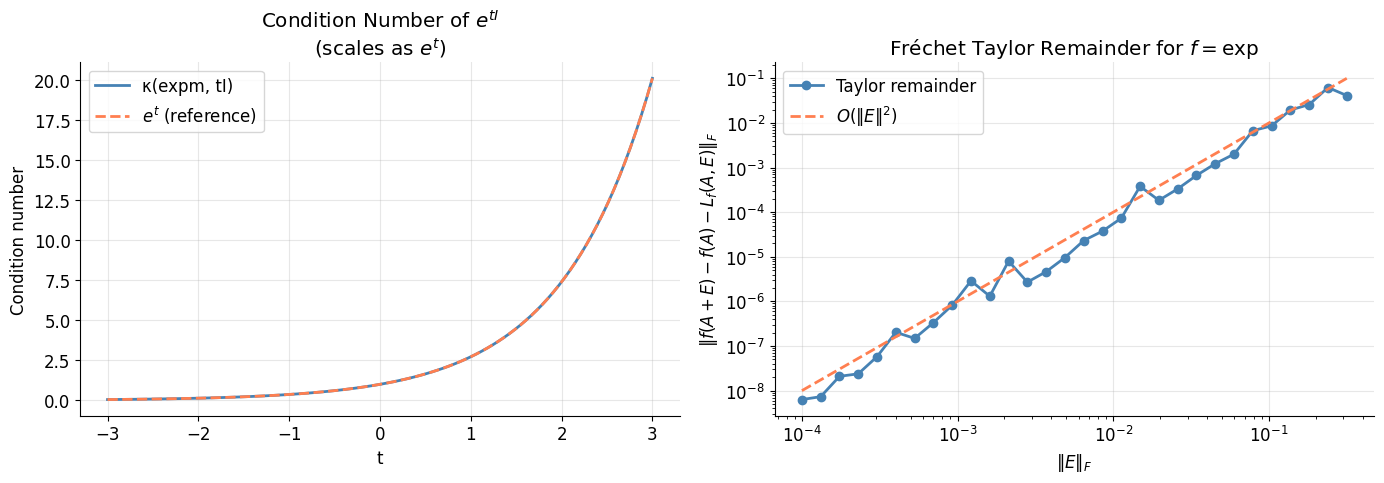

In [11]:
# ── Visualize: Fréchet Derivative & Condition Number ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: condition number of expm as function of t (A = tI) ──
t_vals = np.linspace(-3, 3, 100)
kappa_vals = []
for t in t_vals:
    A_tI = t * np.eye(3)
    E_rand = rng.standard_normal((3, 3))
    E_rand /= np.linalg.norm(E_rand, 'fro')
    L = frechet_expm_block(A_tI, E_rand)
    kappa_vals.append(np.linalg.norm(L, 'fro'))

axes[0].plot(t_vals, kappa_vals, color=PRIMARY, label='κ(expm, tI)')
axes[0].plot(t_vals, np.exp(t_vals), '--', color=SECONDARY, label='$e^t$ (reference)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Condition number')
axes[0].set_title('Condition Number of $e^{tI}$\n(scales as $e^t$)')
axes[0].legend()

# ── Right: Taylor error vs ‖E‖ ──
A_f = rng.standard_normal((4, 4))
A_f = (A_f + A_f.T) / 2

E_norms = np.logspace(-4, -0.5, 30)
taylor_errs = []
for enrm in E_norms:
    E_dir = rng.standard_normal((4, 4))
    E_dir = E_dir / np.linalg.norm(E_dir, 'fro') * enrm
    L = frechet_expm_block(A_f, E_dir)
    err_t = np.linalg.norm(la.expm(A_f + E_dir) - la.expm(A_f) - L, 'fro')
    taylor_errs.append(err_t)

axes[1].loglog(E_norms, taylor_errs, 'o-', color=PRIMARY, label='Taylor remainder')
axes[1].loglog(E_norms, np.array(E_norms)**2, '--', color=SECONDARY, label='$O(\\|E\\|^2)$')
axes[1].set_xlabel('$\\|E\\|_F$')
axes[1].set_ylabel('$\\|f(A+E) - f(A) - L_f(A,E)\\|_F$')
axes[1].set_title('Fréchet Taylor Remainder for $f = \\exp$')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7.  Matrix Logarithm

### 7.1  Definition & Existence

The **matrix logarithm** $\log A$ is a matrix $X$ such that $e^X = A$. It is the inverse of the matrix exponential, but:

- **Non-unique**: Multiple $X$ satisfy $e^X = A$ (like branches of scalar $\log$)
- **Principal logarithm**: $\log A$ with eigenvalues in the strip $\{z : -\pi < \text{Im}(z) < \pi\}$
- **Existence**: $A$ has a real logarithm iff every real negative eigenvalue has even multiplicity

**Spectral formula** (for $A = Q\Lambda Q^{-1}$ with no negative real eigenvalues):
$$\log A = Q\, \mathrm{diag}(\log \lambda_1, \ldots, \log \lambda_n)\, Q^{-1}$$

### 7.2  Inverse Scaling and Squaring

Analogous to expm:
1. **Scale**: $A^{1/2^s}$ via repeated square roots, until $\|A^{1/2^s} - I\|$ is small
2. **Padé**: $\log A^{1/2^s} \approx r_{p,p}(A^{1/2^s} - I)$ (Padé of $\log(1+X)$)
3. **Unscale**: $\log A = 2^s \log A^{1/2^s}$

### 7.3  Geodesics on the PSD Cone

For $A, B \succ 0$, the **geodesic** (shortest path in the affine-invariant metric) is:
$$\Gamma(t) = A^{1/2} (A^{-1/2} B A^{-1/2})^t A^{1/2}, \quad t \in [0,1]$$

The midpoint ($t=1/2$) is the **geometric mean** $A \# B = A^{1/2}(A^{-1/2}BA^{-1/2})^{1/2}A^{1/2}$.

In [12]:
# ── Matrix Logarithm & PSD Geodesics ──────────────────────────────────────────

def logm_spectral(A):
    """Matrix log via spectral decomposition (for symmetric positive definite A).

    Args:
        A: Symmetric positive definite matrix.  Shape: (n, n)

    Returns:
        logA: Principal matrix logarithm.       Shape: (n, n)
    """
    eigvals, Q = la.eigh(A)
    if np.any(eigvals <= 0):
        raise ValueError('A must be positive definite for real logarithm.')
    return Q @ np.diag(np.log(eigvals)) @ Q.T


def psd_geodesic(A, B, t):
    """Geodesic between PSD matrices A and B at time t ∈ [0,1].

    Γ(t) = A^{1/2} (A^{-1/2} B A^{-1/2})^t A^{1/2}

    Args:
        A, B: Symmetric positive definite matrices.  Shape: (n, n)
        t:    Interpolation parameter in [0, 1].

    Returns:
        Gamma_t: PSD matrix on geodesic.             Shape: (n, n)
    """
    eigvals_A, Q_A = la.eigh(A)
    A_half    = Q_A @ np.diag(np.sqrt(eigvals_A))     @ Q_A.T
    A_inv_half = Q_A @ np.diag(1.0 / np.sqrt(eigvals_A)) @ Q_A.T

    M = A_inv_half @ B @ A_inv_half

    # M^t via spectral
    eigvals_M, Q_M = la.eigh(M)
    M_t = Q_M @ np.diag(eigvals_M ** t) @ Q_M.T

    return A_half @ M_t @ A_half


def make_psd(n, min_eig=0.5, rng=rng):
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    lams = min_eig + rng.exponential(1.0, n)
    return Q @ np.diag(lams) @ Q.T


# ── Verify logm ────────────────────────────────────────────────────────────────
n = 4
A_pd = make_psd(n)

logA_spec  = logm_spectral(A_pd)
logA_scipy = la.logm(A_pd).real
explog_A   = la.expm(logA_spec)

print('Matrix logarithm verification:')
err_match  = np.linalg.norm(logA_spec - logA_scipy, 'fro')
err_inv    = np.linalg.norm(explog_A - A_pd, 'fro')
check(err_match < 1e-8, f'Spectral logm matches scipy.logm   (‖err‖_F = {err_match:.2e})')
check(err_inv   < 1e-8, f'exp(log(A)) = A                     (‖err‖_F = {err_inv:.2e})')

# Geodesic endpoints
B_pd = make_psd(n)
Gamma0 = psd_geodesic(A_pd, B_pd, 0.0)
Gamma1 = psd_geodesic(A_pd, B_pd, 1.0)
print('\nPSD geodesic verification:')
check(np.linalg.norm(Gamma0 - A_pd, 'fro') < 1e-8, 'Γ(0) = A')
check(np.linalg.norm(Gamma1 - B_pd, 'fro') < 1e-8, 'Γ(1) = B')

# Midpoint is positive definite
Gamma_half = psd_geodesic(A_pd, B_pd, 0.5)
evals_mid  = la.eigh(Gamma_half, eigvals_only=True)
check(np.all(evals_mid > 0), f'Γ(1/2) ≻ 0  (min eigenvalue = {evals_mid.min():.4f})')

Matrix logarithm verification:
  [PASS]  Spectral logm matches scipy.logm   (‖err‖_F = 2.02e-15)
  [PASS]  exp(log(A)) = A                     (‖err‖_F = 2.56e-15)

PSD geodesic verification:
  [PASS]  Γ(0) = A
  [PASS]  Γ(1) = B
  [PASS]  Γ(1/2) ≻ 0  (min eigenvalue = 0.8768)


True

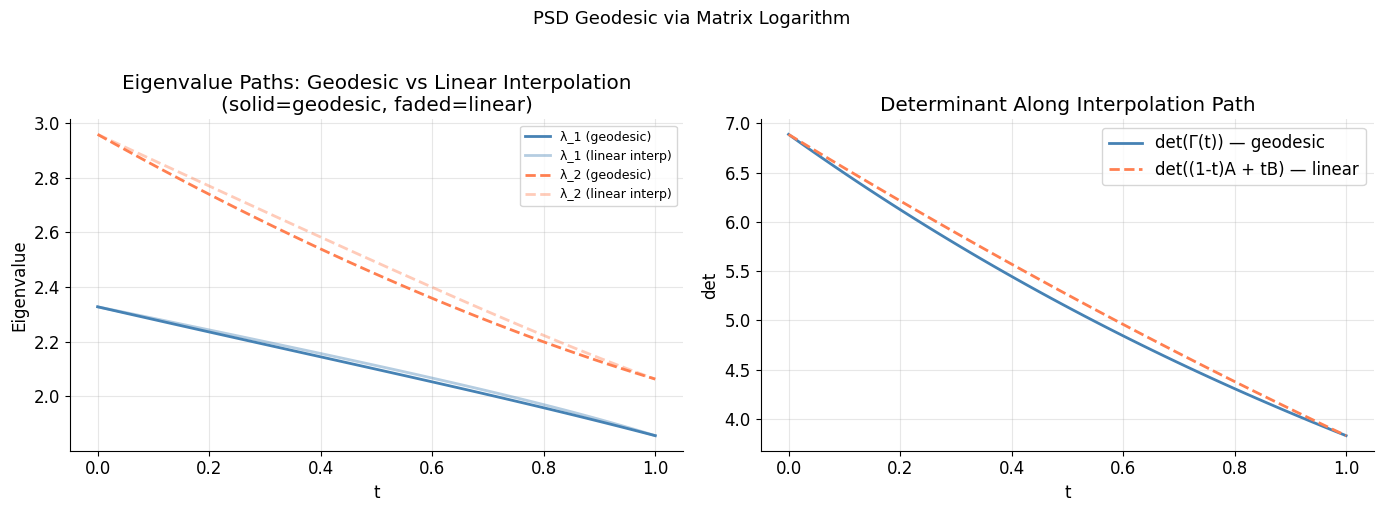

In [13]:
# ── Visualize: PSD Geodesic & Eigenvalue Interpolation ────────────────────────

n = 2
A2 = make_psd(n, min_eig=1.0)
B2 = make_psd(n, min_eig=1.0)

t_vals = np.linspace(0, 1, 50)
geo_evals  = []
lin_evals  = []

for t in t_vals:
    G = psd_geodesic(A2, B2, t)
    L = (1 - t) * A2 + t * B2    # linear interpolation (not geodesic)
    geo_evals.append(np.sort(la.eigh(G, eigvals_only=True)))
    lin_evals.append(np.sort(la.eigh(L, eigvals_only=True)))

geo_evals = np.array(geo_evals)
lin_evals = np.array(lin_evals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (color, ls) in enumerate(zip([PRIMARY, SECONDARY], ['-', '--'])):
    axes[0].plot(t_vals, geo_evals[:, i], ls, color=color, label=f'λ_{i+1} (geodesic)')
    axes[0].plot(t_vals, lin_evals[:, i], ls, color=color, alpha=0.4, label=f'λ_{i+1} (linear interp)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Eigenvalue Paths: Geodesic vs Linear Interpolation\n(solid=geodesic, faded=linear)')
axes[0].legend(fontsize=9)

# Determinant along paths (geodesic preserves positive definiteness more stably)
dets_geo = [np.linalg.det(psd_geodesic(A2, B2, t)) for t in t_vals]
dets_lin = [np.linalg.det((1-t)*A2 + t*B2) for t in t_vals]
axes[1].plot(t_vals, dets_geo, color=PRIMARY,   label='det(Γ(t)) — geodesic')
axes[1].plot(t_vals, dets_lin, '--', color=SECONDARY, label='det((1-t)A + tB) — linear')
axes[1].set_xlabel('t'); axes[1].set_ylabel('det')
axes[1].set_title('Determinant Along Interpolation Path')
axes[1].legend()

plt.suptitle('PSD Geodesic via Matrix Logarithm', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8.  Application: Linear ODE Systems

### 8.1  Exact Solution via Matrix Exponential

The autonomous linear system $\dot{x} = Ax$, $x(0) = x_0$ has the **exact solution**:
$$\boxed{x(t) = e^{tA} x_0}$$

For non-autonomous: $\dot{x} = A(t)x$ — only solvable in closed form when $A(t_1)$ and $A(t_2)$ commute for all $t_1, t_2$.

**Stability**: The zero solution is:
- **Asymptotically stable** iff all eigenvalues of $A$ have negative real part
- **Stable (Lyapunov)** iff all eigenvalues have $\text{Re}(\lambda) \leq 0$, with purely imaginary eigenvalues being non-defective
- **Unstable** if any eigenvalue has positive real part

### 8.2  Exponential Integrators

For $\dot{x} = Ax + g(t, x)$ (stiff + nonlinear), the **exponential Euler** scheme:
$$x_{k+1} = e^{hA} x_k + h\, \varphi_1(hA)\, g(t_k, x_k)$$

where $\varphi_1(Z) = (e^Z - I)/Z$ is the **$\varphi$-function**. This avoids step-size restrictions from stiffness in the linear part.

In [14]:
# ── Linear ODE Systems via Matrix Exponential ─────────────────────────────────

def phi1(A):
    """Compute φ₁(A) = (e^A - I) A^{-1} = ∫₀¹ e^{sA} ds via the block trick.

    Uses: exp([[A, I], [0, 0]]) = [[e^A, φ₁(A)], [0, I]]

    Args:
        A: Square matrix.  Shape: (n, n)

    Returns:
        phi1_A: φ₁(A).     Shape: (n, n)
    """
    n = A.shape[0]
    M = np.block([[A, np.eye(n)], [np.zeros((n, n)), np.zeros((n, n))]])
    expM = la.expm(M)
    return expM[:n, n:]


def solve_ode_expm(A, x0, t_span, n_steps):
    """Exact ODE solution x(t) = e^{tA} x0 evaluated at n_steps time points.

    Args:
        A:       System matrix.     Shape: (n, n)
        x0:      Initial condition. Shape: (n,)
        t_span:  (t0, tf) tuple.
        n_steps: Number of time steps.

    Returns:
        ts:   Time points.          Shape: (n_steps,)
        xs:   Solution trajectory.  Shape: (n_steps, n)
    """
    ts = np.linspace(t_span[0], t_span[1], n_steps)
    xs = np.array([la.expm(t * A) @ x0 for t in ts])
    return ts, xs


def expeuler(A, g, x0, t_span, n_steps):
    """Exponential Euler integrator for ẋ = Ax + g(t, x).

    Args:
        A:       Linear part.          Shape: (n, n)
        g:       Nonlinear part, callable g(t, x) -> Shape: (n,)
        x0:      Initial condition.    Shape: (n,)
        t_span:  (t0, tf) tuple.
        n_steps: Number of steps.

    Returns:
        ts: Time array.                Shape: (n_steps,)
        xs: Trajectory.                Shape: (n_steps, n)
    """
    ts = np.linspace(t_span[0], t_span[1], n_steps)
    h  = (t_span[1] - t_span[0]) / (n_steps - 1)
    xs = [x0.copy()]
    eAh   = la.expm(h * A)
    phi1h = phi1(h * A)
    for k in range(n_steps - 1):
        xk = xs[-1]
        xs.append(eAh @ xk + h * phi1h @ g(ts[k], xk))
    return ts, np.array(xs)


# ── Example 1: 2D Harmonic Oscillator  ẋ = [[0,1],[-ω²,0]] x ─────────────────
omega = 2.0
A_osc = np.array([[0, 1], [-omega**2, 0]])
x0_osc = np.array([1.0, 0.0])
ts_osc, xs_osc = solve_ode_expm(A_osc, x0_osc, (0, 4*np.pi/omega), 500)

# Analytical: x(t) = cos(ωt), ẋ(t) = -ω sin(ωt)
x_anal = np.cos(omega * ts_osc)
err_osc = np.max(np.abs(xs_osc[:, 0] - x_anal))
check(err_osc < 1e-10, f'Harmonic oscillator: max |x_num - x_anal| = {err_osc:.2e}')

# ── Example 2: Stability classification ───────────────────────────────────────
print('\nStability classification:')
systems = [
    ('Asymptotically stable', np.array([[-1, 0.5], [0, -2]])),
    ('Center (stable)',       np.array([[0, 1], [-1, 0]])),
    ('Unstable saddle',       np.array([[1, 0], [0, -2]])),
]
for name, A_ex in systems:
    evals = np.linalg.eigvals(A_ex)
    max_re = np.max(evals.real)
    print(f'  {name}: λ = {np.round(evals, 2)}, max Re(λ) = {max_re:.2f}')

  [PASS]  Harmonic oscillator: max |x_num - x_anal| = 0.00e+00

Stability classification:
  Asymptotically stable: λ = [-1. -2.], max Re(λ) = -1.00
  Center (stable): λ = [0.+1.j 0.-1.j], max Re(λ) = 0.00
  Unstable saddle: λ = [ 1. -2.], max Re(λ) = 1.00


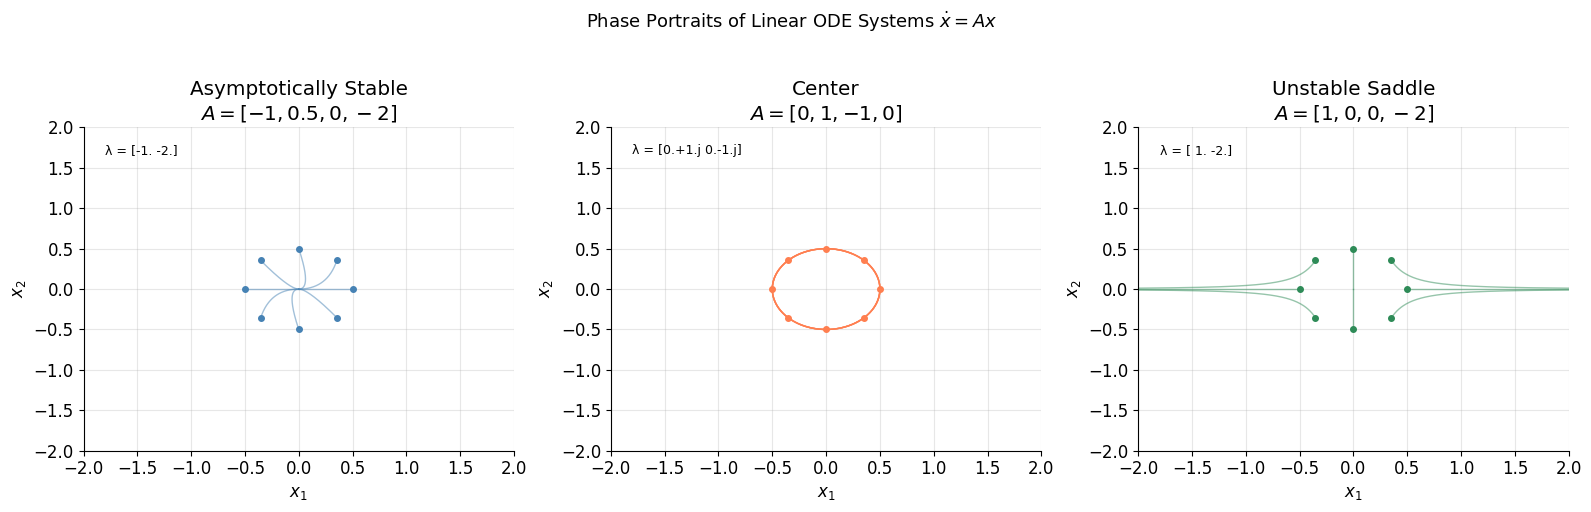

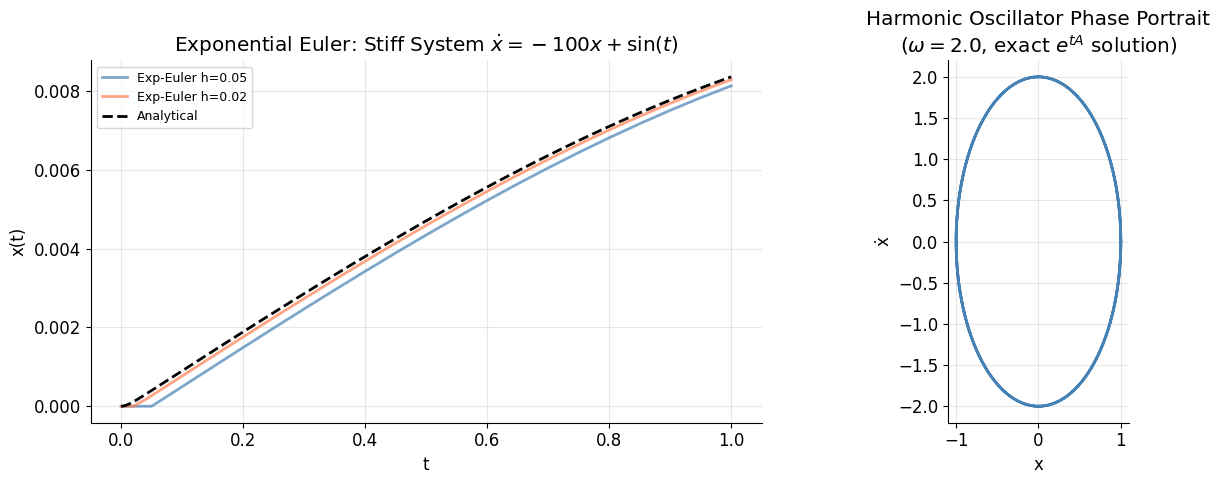

In [15]:
# ── Visualize: ODE Solutions & Phase Portraits ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

t_span = (0, 6)
n_pts  = 400

systems_plot = [
    ('Asymptotically Stable\n$A=[{-1, 0.5},{0,-2}]$',
     np.array([[-1, 0.5], [0, -2]]), PRIMARY),
    ('Center\n$A=[{0, 1},{-1, 0}]$',
     np.array([[0, 1], [-1, 0]]), SECONDARY),
    ('Unstable Saddle\n$A=[{1, 0},{0,-2}]$',
     np.array([[1, 0], [0, -2]]), TERTIARY),
]

for ax, (title, A_ex, color) in zip(axes, systems_plot):
    # Multiple initial conditions
    for angle in np.linspace(0, 2*np.pi, 8, endpoint=False):
        x0 = 0.5 * np.array([np.cos(angle), np.sin(angle)])
        ts, xs = solve_ode_expm(A_ex, x0, t_span, n_pts)
        ax.plot(xs[:, 0], xs[:, 1], color=color, alpha=0.5, linewidth=1)
        ax.plot(xs[0, 0], xs[0, 1], 'o', color=color, markersize=4)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title)
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    evals = np.round(np.linalg.eigvals(A_ex), 2)
    ax.text(0.05, 0.95, f'λ = {evals}', transform=ax.transAxes,
            fontsize=9, va='top')

plt.suptitle('Phase Portraits of Linear ODE Systems $\\dot{x} = Ax$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Exponential Euler for stiff + nonlinear system ────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# ẋ = -100x + sin(t)  (stiff linear + nonlinear forcing)
A_stiff = np.array([[-100.0]])
g_force = lambda t, x: np.array([np.sin(t)])
x0_stiff = np.array([0.0])

# Analytical: x(t) = sin(t)/(1+100²) * (... Laplace solution)
# x(t) = [sin(t)·100 - cos(t) + e^{-100t}] / (100²+1)  (particular + homogeneous)
ts_s = np.linspace(0, 1, 500)
x_anal_stiff = (100*np.sin(ts_s) - np.cos(ts_s) + np.exp(-100*ts_s)) / (100**2 + 1)

for h_step, color, label in [(0.05, PRIMARY, 'h=0.05'), (0.02, SECONDARY, 'h=0.02')]:
    n_s = int(1.0 / h_step) + 1
    ts_ee, xs_ee = expeuler(A_stiff, g_force, x0_stiff, (0, 1), n_s)
    axes2[0].plot(ts_ee, xs_ee[:, 0], '-', color=color, alpha=0.7, label=f'Exp-Euler {label}')

axes2[0].plot(ts_s, x_anal_stiff, 'k--', linewidth=2, label='Analytical')
axes2[0].set_xlabel('t'); axes2[0].set_ylabel('x(t)')
axes2[0].set_title('Exponential Euler: Stiff System $\\dot{x}=-100x+\\sin(t)$')
axes2[0].legend(fontsize=9)

# Harmonic oscillator solution
axes2[1].plot(xs_osc[:, 0], xs_osc[:, 1], color=PRIMARY)
axes2[1].set_xlabel('x'); axes2[1].set_ylabel('ẋ')
axes2[1].set_title(f'Harmonic Oscillator Phase Portrait\n($\\omega={omega}$, exact $e^{{tA}}$ solution)')
axes2[1].set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 9.  Extensions & Advanced Topics

### 9.1  Further Matrix Functions

| Function | Definition | Application |
|----------|-----------|-------------|
| $\cos A$, $\sin A$ | Via $e^{iA}$: $\cos A = \frac{e^{iA}+e^{-iA}}{2}$ | Second-order ODEs $\ddot{x}+Ax=0$ |
| $A^t$ (fractional power) | Via $e^{t \log A}$, $A \succ 0$ | Operator interpolation, PSD geodesics |
| $\text{sign}(A)$ | $A (A^2)^{-1/2}$ | Polar decomposition, Riccati equations |
| $\cosh A$, $\sinh A$ | Analogy with scalar | Lorentz boosts, hyperbolic geometry |

### 9.2  The Polar Decomposition

Every invertible $A = UP$ where $U$ is unitary and $P = (A^*A)^{1/2}$ is PSD (the **polar factor** and **positive part**). This uses the matrix square root and is the matrix analogue of $z = |z| e^{i\theta}$.

### 9.3  Connections to Other Notebooks

| Notebook | Connection |
|----------|------------|
| **Self-Adjoint Operators** | Spectral theorem enables $f(A) = Q f(\Lambda) Q^\top$ for symmetric $A$ |
| **Lie Groups** | $\exp : \mathfrak{so}(3) \to \text{SO}(3)$ is exactly `expm`; BCH governs composition |
| **Matrix Manifolds** | Geodesics on SPD, Stiefel, Grassmann manifolds all use `expm`/`logm` |
| **Perturbation Theory** | Fréchet derivative is the tool for eigenvalue sensitivity analysis |
| **Optimal Control** | Solution of continuous-time algebraic Riccati equation via matrix sign function |

In [16]:
# ── Matrix Trigonometric Functions & Polar Decomposition ─────────────────────

def matrix_cos(A):
    """cos(A) = (e^{iA} + e^{-iA}) / 2."""
    eA  = la.expm(1j * A)
    emA = la.expm(-1j * A)
    return ((eA + emA) / 2).real


def matrix_sin(A):
    """sin(A) = (e^{iA} - e^{-iA}) / (2i)."""
    eA  = la.expm(1j * A)
    emA = la.expm(-1j * A)
    return ((eA - emA) / (2j)).real


def polar_decomposition(A):
    """Compute polar decomposition A = U P where U is unitary, P = (A*A)^{1/2} is PSD.

    Args:
        A: Invertible square matrix.  Shape: (n, n)

    Returns:
        U: Unitary matrix.            Shape: (n, n)
        P: PSD matrix (A*A)^{1/2}.    Shape: (n, n)
    """
    # P = (A^T A)^{1/2}
    AtA = A.T @ A
    eigvals, Q = la.eigh(AtA)
    P = Q @ np.diag(np.sqrt(np.abs(eigvals))) @ Q.T
    U = A @ np.linalg.inv(P)
    return U, P


# ── Verify matrix trig identities ─────────────────────────────────────────────
print('Matrix trigonometric functions:')
A_sym = rng.standard_normal((4, 4))
A_sym = (A_sym + A_sym.T) / 4

# sin²(A) + cos²(A) = I  (for commuting sin and cos, which it is since they share eigenbasis)
cosA = matrix_cos(A_sym)
sinA = matrix_sin(A_sym)
identity_err = np.linalg.norm(cosA @ cosA + sinA @ sinA - np.eye(4), 'fro')
check(identity_err < 1e-10, f'cos²(A) + sin²(A) = I  (‖err‖_F = {identity_err:.2e})')

# e^{iA} = cos(A) + i sin(A)
euler_err = np.linalg.norm(la.expm(1j * A_sym) - (cosA + 1j * sinA), 'fro')
check(euler_err < 1e-10, f"Matrix Euler: e^{{iA}} = cos(A)+i·sin(A)  (‖err‖_F = {euler_err:.2e})")

# Polar decomposition
print('\nPolar decomposition:')
A_inv = rng.standard_normal((4, 4))
A_inv = A_inv + 4 * np.eye(4)    # make well-conditioned
U_pol, P_pol = polar_decomposition(A_inv)

recon_err = np.linalg.norm(U_pol @ P_pol - A_inv, 'fro')
unitary_err = np.linalg.norm(U_pol.T @ U_pol - np.eye(4), 'fro')
psd_check = np.all(la.eigh(P_pol, eigvals_only=True) >= -ATOL)

check(recon_err  < 1e-8, f'A = U·P reconstruction   (‖err‖_F = {recon_err:.2e})')
check(unitary_err < 1e-8, f'U is orthogonal          (‖UᵀU-I‖_F = {unitary_err:.2e})')
check(psd_check,          f'P is positive semidefinite')

# Summary of all methods
print('\n─── Method Summary ─────────────────────────────────────────────────────────')
print('  f(A) definition:    Jordan form (most general), power series, Cauchy integral')
print('  Cayley-Hamilton:    A^n reduces to lower-degree polynomial in A')
print('  Numerical expm:     Padé [13/13] + scaling-and-squaring (scipy default)')
print('  BCH formula:        log(e^A e^B) = A + B + [A,B]/2 + higher commutators')
print('  Fréchet derivative: f(A+E) ≈ f(A) + L_f(A,E) — sensitivity of f to A')
print('  Matrix log/geodesic: Γ(t) = A^{1/2}(A^{-1/2}BA^{-1/2})^t A^{1/2} on PSD cone')

Matrix trigonometric functions:
  [PASS]  cos²(A) + sin²(A) = I  (‖err‖_F = 1.59e-16)
  [PASS]  Matrix Euler: e^{iA} = cos(A)+i·sin(A)  (‖err‖_F = 0.00e+00)

Polar decomposition:
  [PASS]  A = U·P reconstruction   (‖err‖_F = 2.01e-15)
  [PASS]  U is orthogonal          (‖UᵀU-I‖_F = 1.22e-15)
  [PASS]  P is positive semidefinite

─── Method Summary ─────────────────────────────────────────────────────────
  f(A) definition:    Jordan form (most general), power series, Cauchy integral
  Cayley-Hamilton:    A^n reduces to lower-degree polynomial in A
  Numerical expm:     Padé [13/13] + scaling-and-squaring (scipy default)
  BCH formula:        log(e^A e^B) = A + B + [A,B]/2 + higher commutators
  Fréchet derivative: f(A+E) ≈ f(A) + L_f(A,E) — sensitivity of f to A
  Matrix log/geodesic: Γ(t) = A^{1/2}(A^{-1/2}BA^{-1/2})^t A^{1/2} on PSD cone


---
## Summary

| Concept | Key Result |
|---------|------------|
| **$f(A)$ via Jordan form** | $f(J_m(\lambda))$ involves derivatives $f^{(k)}(\lambda)/k!$ on super-diagonals |
| **Power series** | $e^A = \sum A^k/k!$ — converges for any $A$, unstable for large $\|A\|$ |
| **Cayley-Hamilton** | $p_A(A) = 0$: reduces $A^n$ to polynomial of degree $< n$ |
| **Padé + scaling/squaring** | Rational approximation; [13/13] achieves machine precision for any $\|A\|$ |
| **BCH formula** | $\log(e^A e^B) = A + B + \frac{1}{2}[A,B] + \cdots$ — measures non-commutativity |
| **Fréchet derivative** | $L_{\exp}(A, E) = \int_0^1 e^{(1-s)A}\!E\,e^{sA}\,ds$ — linearization of $f$ at $A$ |
| **Matrix log** | Inverse of expm; enables geodesics on PSD cone and Lie group integration |
| **Linear ODEs** | $x(t) = e^{tA}x_0$ — exact, no step-size restriction; forms basis of exponential integrators |

Matrix functions are the bridge between linear algebra and analysis: they allow the full power of smooth function theory to be applied to the algebraic setting of matrices, unlocking exact solutions, geometric structures, and stable numerical algorithms.